# 15: Error Breakdown Analysis 2022
**Objective:** Analyze the residuals of the 2022 validation run to identify which quarters and seasons contribute most to the MAE. This will help refine the momentum and festive logic.

Revenue Error by Quarter (MAE and Mean Bias):
         Error_Revenue   Bias_Revenue
Quarter                              
1        672213.908164 -443485.167022
2        722130.733198 -364865.039235
3        870045.621888 -648292.780754
4        425437.237488  -84752.132739

COGS Error by Quarter (MAE and Mean Bias):
            Error_COGS      Bias_COGS
Quarter                              
1        511709.997258 -222860.019122
2        563074.074939   43879.323924
3        618758.047373  131888.231548
4        431602.802386   89000.970718


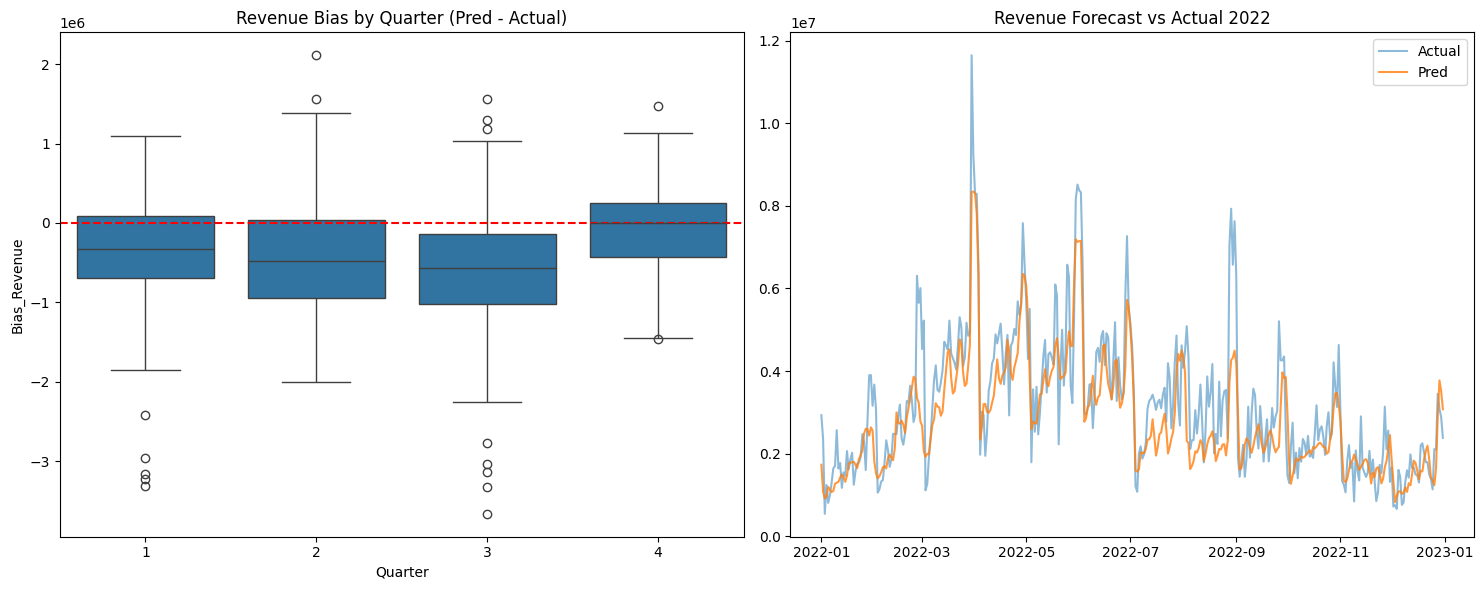

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.metrics import mean_absolute_error

sys.path.append(os.path.abspath('..'))
from src.config import Config
import src.training.pipeline as pipeline

# Manually define helper functions that are nested in run_pipeline
def apply_momentum_local(df, predictions, momentum, last_train_date, target_name):
    days_from_end = (df['Date'] - last_train_date).dt.days
    
    def calculate_multiplier(d):
        if d <= 180:
            return momentum
        else:
            # Sustain logic updated to match pipeline fix: 
            # 180 days 100% momentum, then slow decay (0.01)
            days_after_sustain = d - 180
            decay_weight = np.exp(-0.01 * (days_after_sustain / 365.0))
            return 1 + (momentum - 1) * decay_weight
            
    dynamic_multipliers = days_from_end.apply(calculate_multiplier)
    return predictions * dynamic_multipliers

# 1. Re-run validation to get predictions
sales = pd.read_parquet(Config.SALES_TRAIN_FILE)
sales['Date'] = pd.to_datetime(sales['Date'])
start_date = sales['Date'].min()

full_df = pipeline.extract_features(sales, start_date)
full_df = full_df[full_df['Date'].dt.year >= 2018]

train_df = full_df[full_df['Date'].dt.year < 2022]
val_df = full_df[full_df['Date'].dt.year == 2022].copy()

features = [
    'trend_dampened', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 
    'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos',
    'is_pre_tet', 'is_tet_holiday'
]
targets = ['Revenue', 'COGS']

# Mock the training and prediction to get same results as pipeline
import lightgbm as lgb
import xgboost as xgb

rev_mom, cogs_mom = pipeline.get_dynamic_momentum(train_df)
train_end_date = train_df['Date'].max()

for target in targets:
    lgb_m = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, objective='regression_l1', random_state=42, verbose=-1)
    lgb_m.fit(train_df[features], train_df[target])
    xgb_m = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.03, objective='reg:absoluteerror', random_state=42)
    xgb_m.fit(train_df[features], train_df[target])
    
    p_raw = (lgb_m.predict(val_df[features]) + xgb_m.predict(val_df[features])) / 2
    mom = rev_mom if target == 'Revenue' else cogs_mom
    val_df[f'Pred_{target}'] = apply_momentum_local(val_df, p_raw, mom, train_end_date, target)
    val_df[f'Error_{target}'] = np.abs(val_df[target] - val_df[f'Pred_{target}'])
    val_df[f'Bias_{target}'] = val_df[f'Pred_{target}'] - val_df[target]

# 2. Breakdown by Quarter
val_df['Quarter'] = val_df['Date'].dt.quarter
q_error_rev = val_df.groupby('Quarter')[['Error_Revenue', 'Bias_Revenue']].mean()
q_error_cogs = val_df.groupby('Quarter')[['Error_COGS', 'Bias_COGS']].mean()

print("Revenue Error by Quarter (MAE and Mean Bias):")
print(q_error_rev)
print("\nCOGS Error by Quarter (MAE and Mean Bias):")
print(q_error_cogs)

# 3. Visualizations
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=val_df, x='Quarter', y='Bias_Revenue')
plt.title("Revenue Bias by Quarter (Pred - Actual)")
plt.axhline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(val_df['Date'], val_df['Revenue'], label='Actual', alpha=0.5)
plt.plot(val_df['Date'], val_df[f'Pred_Revenue'], label='Pred', alpha=0.8)
plt.title("Revenue Forecast vs Actual 2022")
plt.legend()
plt.tight_layout()
plt.show()